In [18]:
%load_ext autoreload
%autoreload 2

import os
import sys
import random
from pathlib import Path

import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean" / "large_20grid"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "large_20grid"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

print(f"Project root found at: {PROJECT_ROOT}")
print(f"Loading source from: {SRC_DIR}")

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods import PolicySolver, EnvDataCollector
from rl_methods.fogas_clean import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from rl_methods.dataset_collection import DatasetAnalyzer
from rl_methods.fqi_clean.fqi_solver import FQISolver
from rl_methods.fqi.fqi_evaluator import FQIEvaluator
from rl_methods.data_collection_clean import DiscreteDataBuffer
from rl_methods.data_collection_clean import DatasetAnalyzer

# Now define the dataset path
DATASET_PATH = DATASETS_DIR / "large_10grid_coarse.csv"
DATASET_PATH1 = DATASETS_DIR / "large_20grid_fine.csv"
print(f"Loading dataset from: {DATASET_PATH}")

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading source from: /shared/home/mauro.diaz/work/FOGAS/src
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/large_20grid/large_10grid_coarse.csv
Using device: cuda


### Plotting and Scaling Helpers

In [19]:
def scale_grid(small_grid, factor=2):
    """
    Scales a grid by repeating each cell in rows and columns.
    Example: 10x10 with factor=2 becomes 20x20.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    large_grid[large_grid == "S"] = "."
    large_grid[large_grid == "G"] = "."

    large_grid[0, 0] = "S"
    large_grid[-1, -1] = "G"

    return large_grid


def _grid_major_step(size):
    if size <= 20:
        return 5
    if size <= 80:
        return 10
    return 20


def plot_fogas_grid(grid_data):
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4, interpolation="nearest", origin="upper")

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    ax.set_title(f"FOGAS Environment - {size}x{size} Grid", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]

    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix="", alpha=0.75):
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4, interpolation="nearest", origin="upper")

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    line_styles = ["-", "--", ":", "-."]
    path_colors = ["magenta", "cyan", "yellow", "orange", "lime", "purple"]

    for i, path in enumerate(paths):
        if not path:
            continue

        label = labels[i] if labels and i < len(labels) else f"Path {i + 1}"
        rows, cols = zip(*path)
        color = path_colors[i % len(path_colors)]

        ax.plot(
            cols,
            rows,
            label=label,
            color=color,
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2,
            marker="o",
            markersize=3,
            alpha=alpha,
        )

        ax.scatter(cols[0], rows[0], marker="s", s=60, color=color, zorder=5)
        ax.scatter(cols[-1], rows[-1], marker="*", s=120, color=color, zorder=5)

    ax.set_title(f"FOGAS Path Comparison: {size}x{size} {title_suffix}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

def plot_occupancy_grid(planner, mdp_data, size, title_suffix="", mask_terminals=True):
    """
    Plot the optimal state occupancy from a clean Planner on a square grid.

    Works for 10x10, 20x20, 40x40, etc.
    """
    probs = planner.state_mu_star.detach().cpu().numpy().copy()

    terminal_states = set(mdp_data["pits"]) | {mdp_data["goal"]}

    if mask_terminals:
        for idx in terminal_states:
            probs[idx] = 0.0

    occupancy_grid = probs.reshape(size, size)
    positive_probs = probs[probs > 0]

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    norm = LogNorm(
        vmin=positive_probs.min() if len(positive_probs) else 1e-6,
        vmax=max(probs.max(), 1e-6),
    )

    im = ax.imshow(
        occupancy_grid,
        cmap="YlGnBu",
        norm=norm,
        interpolation="nearest",
        origin="upper",
    )

    # Cell boundaries, same style as plot_fogas_grid
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Adaptive major tick labels
    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    # Mark start, goal, pits, walls
    start = mdp_data["start"]
    goal = mdp_data["goal"]

    start_r, start_c = divmod(start, size)
    goal_r, goal_c = divmod(goal, size)

    ax.scatter(start_c, start_r, marker="s", s=90, color="#457B9D", edgecolor="black", label="Start", zorder=5)
    ax.scatter(goal_c, goal_r, marker="*", s=180, color="#2DC653", edgecolor="black", label="Goal", zorder=5)

    for pit in mdp_data["pits"]:
        r, c = divmod(pit, size)
        ax.scatter(c, r, marker="x", s=80, color="#E63946", linewidths=2, label="Pit" if pit == next(iter(mdp_data["pits"])) else None, zorder=5)

    for wall in mdp_data["walls"]:
        r, c = divmod(wall, size)
        ax.add_patch(
            plt.Rectangle(
                (c - 0.5, r - 0.5),
                1,
                1,
                facecolor="#2C2C2C",
                edgecolor="none",
                alpha=0.85,
                zorder=4,
            )
        )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Log Occupancy Probability", fontsize=10)

    masked_text = "excluding terminal states" if mask_terminals else "including terminal states"
    ax.set_title(
        f"Optimal State Occupancy - {size}x{size} Grid {title_suffix}\n{masked_text}",
        fontsize=14,
        pad=12,
    )
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()

### 10x10 and 20x20 grid used

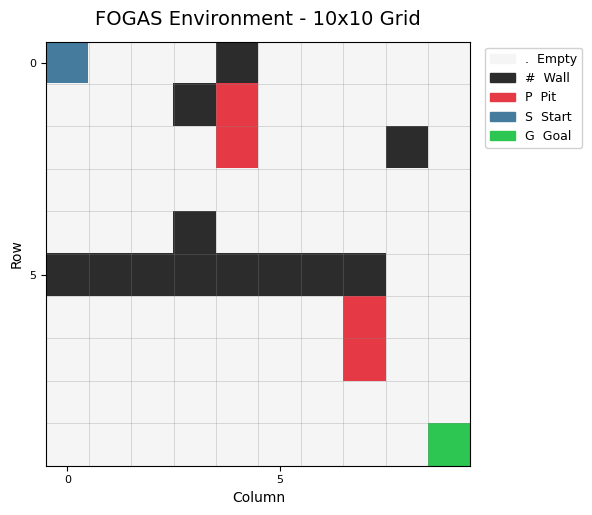

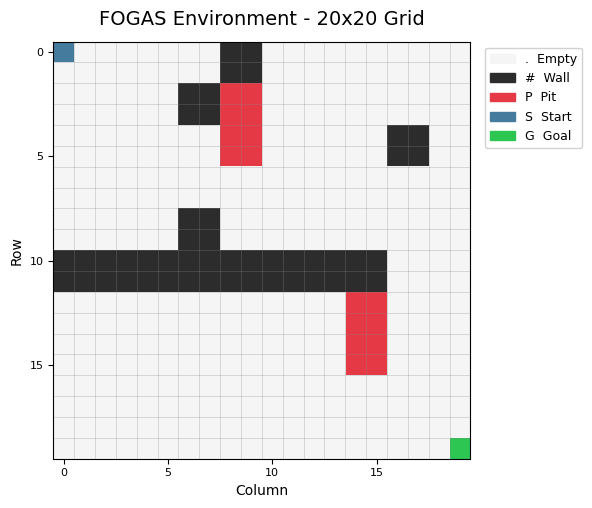

In [3]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]

grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid(grid_10, factor=2)

plot_fogas_grid(grid_10)
plot_fogas_grid(grid_20)

### MDP and Features Helpers

In [20]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    """
    Builds the grid-world MDP data from a character grid.

    What it creates:
    - walls, pits, start, goal from the grid
    - deterministic transition matrix P with 4 actions:
        0 = up, 1 = down, 2 = left, 3 = right
    - reward function:
        goal = +10
        pit = -10
        every other state = -0.01
    - normalized RBF centers in [0, 1] x [0, 1]
    """
    size = grid_data.shape[0]
    N = size * size
    A = 4

    walls = set(np.where(grid_data.flatten() == "#")[0])
    pits = set(np.where(grid_data.flatten() == "P")[0])
    goal = np.where(grid_data.flatten() == "G")[0][0]
    start_node = np.where(grid_data.flatten() == "S")[0][0]

    # Regular Grid Center Generation
    # Target 50% of the total states N.
    target_num_centers = int(N * 0.5)

    # Since centers are laid out as a square meshgrid, use sqrt(target).
    centers_per_side = int(np.sqrt(target_num_centers))

    # Centers live in normalized coordinate space [0, 1].
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(
        np.column_stack([c_x.ravel(), c_y.ravel()]),
        dtype=torch.float64,
    )

    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal:
            return 10.0
        if x_int in pits:
            return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)

    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue

            r, c = divmod(x, size)

            if a == 0:
                r_n, c_n = max(0, r - 1), c
            elif a == 1:
                r_n, c_n = min(size - 1, r + 1), c
            elif a == 2:
                r_n, c_n = r, max(0, c - 1)
            elif a == 3:
                r_n, c_n = r, min(size - 1, c + 1)

            next_s = r_n * size + c_n

            if next_s in walls:
                next_s = x

            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers,
        "walls": walls,
        "pits": pits,
        "goal": goal,
        "start": start_node,
        "reward_fn": reward_fn,
        "P": P,
        "N": N,
        "A": A,
        "gamma": gamma,
    }


def build_clean_mdp_from_grid_data(mdp_data):
    """
    Converts the mdp_data dictionary into fogas_clean-compatible objects.

    Returns:
    - mdp: clean DiscreteMDP
    - planner: clean Planner with optimal policy/value/occupancy computed
    """
    terminal_states = list(mdp_data["pits"]) + [mdp_data["goal"]]

    mdp = DiscreteMDP(
        states=torch.arange(mdp_data["N"]),
        actions=torch.arange(mdp_data["A"]),
        reward_fn=mdp_data["reward_fn"],
        gamma=mdp_data["gamma"],
        x0=mdp_data["start"],
        P=mdp_data["P"],
        terminal_states=terminal_states,
    )

    planner = Planner(mdp)

    return mdp, planner


def get_phi_func(centers, sigma, size, pits, goal, A):
    """
    Returns state-action feature function for FOGAS:
    phi(x, a) = one_hot(a) kron phi_state(x)
    """
    def phi_state(x):
        r, c = divmod(int(x), size)

        coords = torch.tensor(
            [r / (size - 1), c / (size - 1)],
            dtype=torch.float64,
        )

        dist_sq = torch.sum((coords - centers) ** 2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma ** 2))

        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)

        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])

    def phi(x, a):
        state_feat = phi_state(x)
        d_state = state_feat.shape[0]

        out = torch.zeros(A * d_state, dtype=torch.float64)
        start = int(a) * d_state
        out[start:start + d_state] = state_feat

        return out

    return phi


def calculate_local_sigma(centers, k=2):
    """
    Computes an RBF sigma from average k-nearest-neighbor distance.

    This makes sigma adapt to the density of the regular center grid.
    """
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])


def _grid_major_step(size):
    if size <= 20:
        return 5
    if size <= 80:
        return 10
    return 20


def plot_grid_with_centers(grid_data, centers):
    """
    Plots the grid and overlays the RBF feature centers.

    Works for 10x10, 20x20, 40x40, 100x100, etc.
    Centers are stored normalized in [0, 1], then scaled back to grid coordinates.
    """
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    centers_scaled = centers.detach().cpu().numpy() * (size - 1)

    marker_size = max(15, min(80, 250 / np.sqrt(size)))
    ax.scatter(
        centers_scaled[:, 1],
        centers_scaled[:, 0],
        c="blue",
        marker="x",
        s=marker_size,
        label="RBF Feature Centers",
        alpha=0.65,
        linewidths=1.2,
    )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]

    grid_legend = ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        framealpha=0.9,
        title="Grid",
    )
    ax.add_artist(grid_legend)

    ax.legend(
        bbox_to_anchor=(1.02, 0.58),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(f"FOGAS Feature Allocation - {size}x{size}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    plt.tight_layout()
    plt.show()

def compute_optimal_path(planner, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following planner.pi_star.

    It starts from mdp_data["start"], chooses the best action from the optimal
    policy at each state, then uses the transition matrix P to move to the next
    state.

    Stops when:
    - the goal is reached
    - a pit is reached
    - the policy gets stuck
    - max_steps is reached
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]

    path = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))

        if current_state == goal_state or current_state in pits:
            break

        best_a = torch.argmax(planner.pi_star[current_state]).item()
        next_state = torch.argmax(planner.P[current_state * planner.A + best_a]).item()

        if next_state == current_state:
            break

        current_state = next_state

    return path

def sample_policy_path(mdp, mdp_data, size, pi, max_steps=1000, rng=None):
    """
    Sample one trajectory from a policy on a clean DiscreteMDP.

    Args:
        mdp: clean DiscreteMDP
        mdp_data: dict with start, goal, pits
        size: grid side length
        pi: policy tensor with shape (N, A)
    """
    if rng is None:
        rng = np.random.default_rng()

    pi = pi.detach().cpu() if isinstance(pi, torch.Tensor) else torch.as_tensor(pi)

    current_state = int(mdp_data["start"])
    goal_state = int(mdp_data["goal"])
    pits = set(mdp_data["pits"])

    path = []
    states = []
    actions = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))
        states.append(current_state)

        if current_state == goal_state or current_state in pits:
            break

        action_probs = pi[current_state].numpy()
        action_probs = action_probs / action_probs.sum()

        action = int(rng.choice(mdp.A, p=action_probs))
        actions.append(action)

        transition_probs = mdp.P[current_state * mdp.A + action].detach().cpu().numpy()
        next_state = int(rng.choice(mdp.N, p=transition_probs))

        if next_state == current_state:
            break

        current_state = next_state

    return path, states, actions


def sample_multiple_policy_paths(
    mdp,
    mdp_data,
    size,
    pi,
    n_paths=20,
    max_steps=1000,
    seed=None,
):
    rng = np.random.default_rng(seed)

    paths = []
    states_list = []
    actions_list = []

    for _ in range(n_paths):
        path, states, actions = sample_policy_path(
            mdp=mdp,
            mdp_data=mdp_data,
            size=size,
            pi=pi,
            max_steps=max_steps,
            rng=rng,
        )
        paths.append(path)
        states_list.append(states)
        actions_list.append(actions)

    return paths, states_list, actions_list


def unique_paths(paths):
    seen = set()
    out = []

    for path in paths:
        key = tuple(path)
        if key not in seen:
            seen.add(key)
            out.append(path)

    return out


def sample_unique_policy_paths(
    mdp,
    mdp_data,
    size,
    pi,
    n_samples=200,
    max_unique=10,
    max_steps=1000,
    seed=None,
):
    paths, _, _ = sample_multiple_policy_paths(
        mdp=mdp,
        mdp_data=mdp_data,
        size=size,
        pi=pi,
        n_paths=n_samples,
        max_steps=max_steps,
        seed=seed,
    )

    return unique_paths(paths)[:max_unique]

# 10x10 grid

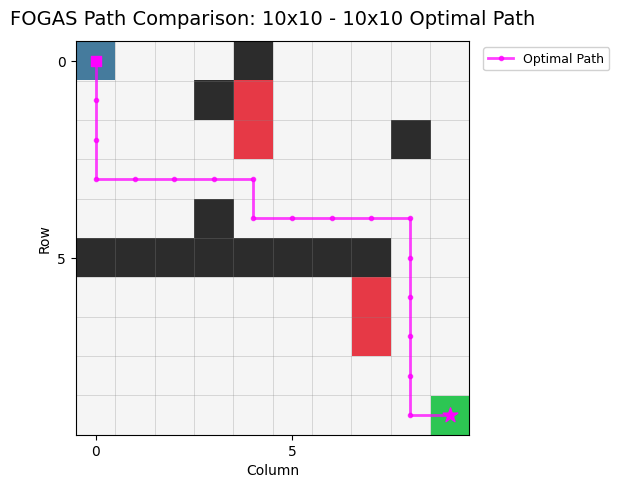

In [21]:
size_10 = grid_10.shape[0]

mdp_data_10 = generate_mdp_regular_grid(grid_10)

centers_10 = mdp_data_10["centers"]
sigma_10 = calculate_local_sigma(centers_10, k=2)

phi_10 = get_phi_func(
    centers_10,
    sigma_10,
    size_10,
    mdp_data_10["pits"],
    mdp_data_10["goal"],
    A=mdp_data_10["A"],
)

mdp_10, planner_10 = build_clean_mdp_from_grid_data(mdp_data_10)
optimal_path_10 = compute_optimal_path(planner_10, mdp_data_10, size=size_10)

plot_agent_paths_with_labels(
    grid_10,
    [optimal_path_10],
    labels=["Optimal Path"],
    title_suffix="- 10x10 Optimal Path",
)


### Data collection with occupancy measure

In [15]:
reset_options = {
    "x0": 0.1,
    "occupancy": 0.9,
}

collector_10 = DiscreteDataBuffer(
    mdp=mdp_10,
    restricted_states=mdp_data_10["walls"],
    reset_probs=reset_options,
    occupancy=planner_10.state_mu_star,   # clean Planner owns this now
    max_steps=200,
    seed=seed,
)

epsilon_policy_10 = (planner_10.pi_star, 0.3)  # 30% random, 70% pi_star

df_10 = collector_10.collect(
    policies=[epsilon_policy_10, "random"],
    proportions=[0.8, 0.2],
    n_steps=10_000,
    episode_based=True,
    extra_terminal_steps=50,
    save_path=str(DATASET_PATH),
    verbose=True,
)

Collected 10000 transitions over 143 episodes.
Policy distribution:
policy_id
0    0.7594
1    0.2406
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    0.8024
x0           0.1976
Name: proportion, dtype: float64
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/large_20grid/large_10grid_coarse.csv


STATE COVERAGE
Total states:              100
Walls:                     12
Terminal states:           5
Visited states:            62
Unvisited non-wall states: 26
State coverage:            70.45%


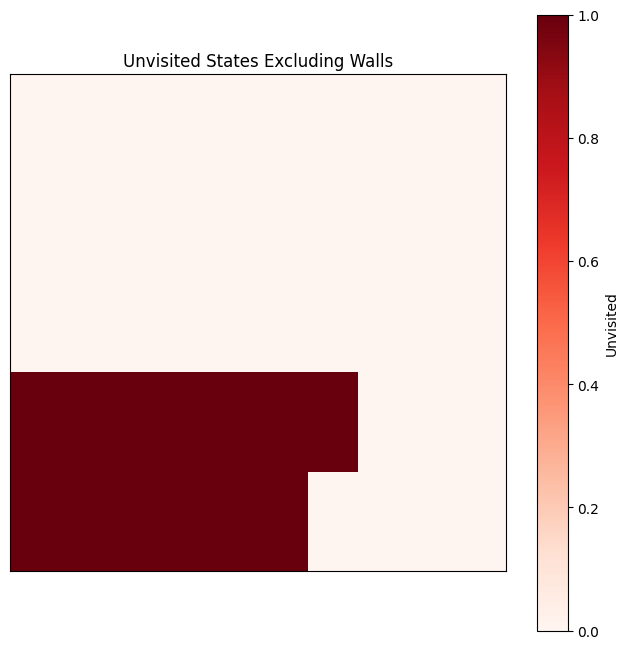

FEATURE COVERAGE
Coverage ratio: 2.082991
Dataset size:   10000
Feature dim:    208
Beta:           1e-06


In [ ]:
# -----------------------------
# Dataset coverage diagnostics
# -----------------------------

df_current = df_10
mdp_current = mdp_10
planner_current = planner_10
mdp_data_current = mdp_data_10
phi_current = phi_10
dataset_path_current = DATASET_PATH
size_current = size_10

# Visited / missing states
visited_states = set(df_current["state"].unique())
wall_states = set(mdp_data_current["walls"])
terminal_states = set(mdp_data_current["pits"]) | {mdp_data_current["goal"]}
all_states = set(range(mdp_current.N))

non_visited_non_walls = all_states - visited_states - wall_states

print("=" * 50)
print("STATE COVERAGE")
print("=" * 50)
print(f"Total states:              {mdp_current.N}")
print(f"Walls:                     {len(wall_states)}")
print(f"Terminal states:           {len(terminal_states)}")
print(f"Visited states:            {len(visited_states)}")
print(f"Unvisited non-wall states: {len(non_visited_non_walls)}")
print(f"State coverage:            {len(visited_states) / (mdp_current.N - len(wall_states)):.2%}")

# Plot unvisited non-wall states
coverage_map = np.zeros((size_current, size_current), dtype=float)

for s in non_visited_non_walls:
    r, c = divmod(s, size_current)
    coverage_map[r, c] = 1.0

plt.figure(figsize=(8, 8))
plt.imshow(coverage_map, cmap="Reds", interpolation="nearest")
plt.title("Unvisited States Excluding Walls")
plt.colorbar(label="Unvisited")
plt.xticks([])
plt.yticks([])
plt.show()

# -----------------------------
# Feature coverage diagnostics
# -----------------------------

# Clean DatasetAnalyzer expects an explicit feature tensor:
# shape = (N, A, d)
Phi_current = torch.stack(
    [
        torch.stack(
            [phi_current(x, a) for a in range(mdp_current.A)],
            dim=0,
        )
        for x in range(mdp_current.N)
    ],
    dim=0,
)

analyzer = DatasetAnalyzer(df_current)

coverage = analyzer.feature_coverage(
    phi=Phi_current,
    optimal_occupancy=planner_current.mu_star,
    beta=1e-6,
    return_details=True,
)

print("=" * 50)
print("FEATURE COVERAGE")
print("=" * 50)
print(f"Coverage ratio: {coverage['coverage_ratio']:.6f}")
print(f"Dataset size:   {coverage['n']}")
print(f"Feature dim:    {Phi_current.shape[-1]}")
print(f"Beta:           {coverage['beta']}")

In [18]:
solver_10 = FOGASSolver(
    mdp=mdp_10,
    phi=phi_10,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_10 = FOGASEvaluator(
    solver=solver_10,
    planner=planner_10,
)

solver_10.run(
    alpha=0.0001 / 2,
    eta=0.00002,
    rho=0.5,
    T=10_000,
    tqdm_print=True,
)

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=10000)


FOGAS: 100%|██████████| 10000/10000 [05:37<00:00, 29.64it/s]


tensor([[0.1886, 0.3659, 0.1861, 0.2593],
        [0.1329, 0.2674, 0.0577, 0.5420],
        [0.1901, 0.2527, 0.0202, 0.5370],
        [0.3246, 0.3566, 0.0157, 0.3031],
        [0.2590, 0.4264, 0.0189, 0.2957],
        [0.1366, 0.3153, 0.0187, 0.5293],
        [0.1082, 0.1875, 0.0155, 0.6887],
        [0.1780, 0.1843, 0.0254, 0.6124],
        [0.2805, 0.2362, 0.0677, 0.4156],
        [0.3027, 0.2620, 0.1493, 0.2860],
        [0.0285, 0.7457, 0.1043, 0.1216],
        [0.0239, 0.6144, 0.0429, 0.3188],
        [0.0663, 0.5389, 0.0200, 0.3748],
        [0.1719, 0.6425, 0.0136, 0.1719],
        [0.0060, 0.9889, 0.0026, 0.0026],
        [0.0760, 0.6840, 0.0083, 0.2317],
        [0.0835, 0.4954, 0.0078, 0.4133],
        [0.1558, 0.4222, 0.0151, 0.4069],
        [0.2380, 0.4398, 0.0528, 0.2694],
        [0.2492, 0.4133, 0.1504, 0.1871],
        [0.0117, 0.6850, 0.1263, 0.1769],
        [0.0092, 0.4975, 0.0627, 0.4305],
        [0.0285, 0.4263, 0.0337, 0.5116],
        [0.0840, 0.6421, 0.0227, 0

In [21]:
terminal_states_10 = list(mdp_data_10["pits"]) + [mdp_data_10["goal"]]

num_trajectories = 100
max_steps = 200

def discounted_return(traj, gamma):
    return sum((gamma ** step["step"]) * step["reward"] for step in traj)

returns_10 = []
successes_10 = []

for i in range(num_trajectories):
    traj = evaluator_10.simulate_trajectory(
        policy_mode="greedy",
        max_steps=max_steps,
        seed=seed + i,
        goal_state=mdp_data_10["goal"],
        terminal_states=terminal_states_10,
    )

    returns_10.append(discounted_return(traj, mdp_10.gamma))
    successes_10.append(
        bool(traj) and traj[-1]["next_state"] == mdp_data_10["goal"]
    )

returns_10 = np.array(returns_10, dtype=float)
successes_10 = np.array(successes_10, dtype=bool)

# Optional optimal comparison
optimal_returns_10 = []
optimal_successes_10 = []

for i in range(num_trajectories):
    traj_opt = evaluator_10.simulate_trajectory(
        pi=planner_10.pi_star,
        max_steps=max_steps,
        seed=seed + i,
        goal_state=mdp_data_10["goal"],
        terminal_states=terminal_states_10,
    )

    optimal_returns_10.append(discounted_return(traj_opt, mdp_10.gamma))
    optimal_successes_10.append(
        bool(traj_opt) and traj_opt[-1]["next_state"] == mdp_data_10["goal"]
    )

optimal_returns_10 = np.array(optimal_returns_10, dtype=float)
optimal_successes_10 = np.array(optimal_successes_10, dtype=bool)

print("=" * 50)
print("FOGAS SIMULATION METRICS")
print("=" * 50)
print(f"Average return:       {returns_10.mean():.4f}")
print(f"Return std:           {returns_10.std(ddof=1):.4f}")
print(f"Optimal avg return:   {optimal_returns_10.mean():.4f}")
print(f"Optimal return std:   {optimal_returns_10.std(ddof=1):.4f}")
print(f"Return gap:           {optimal_returns_10.mean() - returns_10.mean():.4f}")
print()
print(f"Success rate:         {successes_10.mean():.2%}")
print(f"Optimal success:      {optimal_successes_10.mean():.2%}")
print(f"Success gap:          {optimal_successes_10.mean() - successes_10.mean():.2%}")

FOGAS SIMULATION METRICS
Average return:       -0.1655
Return std:           0.0000
Optimal avg return:   -0.1655
Optimal return std:   0.0000
Return gap:           0.0000

Success rate:         100.00%
Optimal success:      100.00%
Success gap:          0.00%


## 20x20 grid

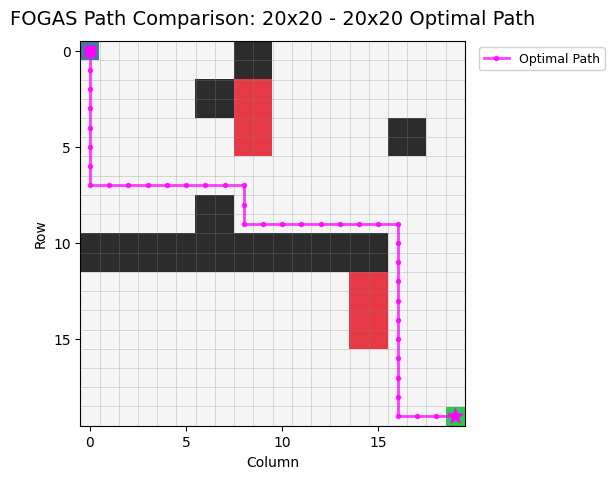

20x20:
  N=400, A=4
  feature_dim=208
Aligned with 10x10: True


In [22]:
# -----------------------------
# 20x20 setup using existing 10x10 feature space
# -----------------------------

grid_20 = scale_grid(grid_10, factor=2)
size_20 = grid_20.shape[0]

mdp_data_20 = generate_mdp_regular_grid(grid_20)

# Reuse the 10x10 feature centers/sigma so phi_10 and phi_20 are aligned.
fixed_centers = centers_10
fixed_sigma = sigma_10

phi_20 = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_20,
    mdp_data_20["pits"],
    mdp_data_20["goal"],
    A=mdp_data_20["A"],
)

mdp_20, planner_20 = build_clean_mdp_from_grid_data(mdp_data_20)

optimal_path_20 = compute_optimal_path(
    planner_20,
    mdp_data_20,
    size=size_20,
)

plot_agent_paths_with_labels(
    grid_20,
    [optimal_path_20],
    labels=["Optimal Path"],
    title_suffix="- 20x20 Optimal Path",
)

print("20x20:")
print(f"  N={mdp_20.N}, A={mdp_20.A}")
print(f"  feature_dim={phi_20(0, 0).numel()}")
print("Aligned with 10x10:", phi_20(0, 0).numel() == phi_10(0, 0).numel())

## Strategy 1 - Fine data-learning

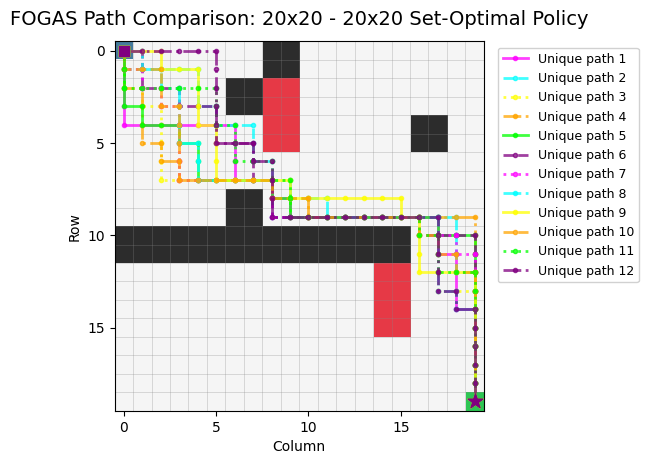

In [23]:
pi_set_20 = planner_20.policy_from_optimal_q(
    mode="set",
    tie_eps=1e-10,
)

paths_20, states_list_20, actions_list_20 = sample_multiple_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=size_20,
    pi=pi_set_20,
    n_paths=30,
    max_steps=500,
    seed=seed,
)

paths_unique_20 = sample_unique_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=size_20,
    pi=pi_set_20,
    n_samples=300,
    max_unique=12,
    max_steps=500,
    seed=seed,
)

labels_20 = [f"Unique path {i + 1}" for i in range(len(paths_unique_20))]

plot_agent_paths_with_labels(
    grid_data=grid_20,
    paths=paths_unique_20,
    labels=labels_20,
    title_suffix="- 20x20 Set-Optimal Policy",
)

In [24]:
# -----------------------------
# Set-optimal policy occupancy
# -----------------------------

# Clean API: policy_from_optimal_q and occupancy_measure live on Planner.
pi_rec_20 = planner_20.policy_from_optimal_q(mode="set", tie_eps=1e-10)
mu_rec_20 = planner_20.occupancy_measure(pi_rec_20)

probs_20 = (
    mu_rec_20
    .reshape(mdp_20.N, mdp_20.A)
    .sum(dim=1)
    .detach()
    .cpu()
    .numpy()
    .copy()
)

terminal_states_20 = set(mdp_data_20["pits"]) | {mdp_data_20["goal"]}

for idx in terminal_states_20:
    probs_20[idx] = 0.0

occupancy_grid_20 = probs_20.reshape(size_20, size_20)

In [33]:
# -----------------------------
# 20x20 dataset collection matching old 20gird_opt as closely as possible
# -----------------------------

pi_rec_20 = planner_20.policy_from_optimal_q(mode="set", tie_eps=1e-10)
mu_rec_20 = planner_20.occupancy_measure(pi_rec_20)

# Old EnvDataCollector sampled occupancy resets from mdp.state_mu_star.
# For the set-optimal policy, this is the corresponding state occupancy.
state_occupancy_20 = (
    mu_rec_20
    .reshape(mdp_20.N, mdp_20.A)
    .sum(dim=1)
    .detach()
    .cpu()
    .numpy()
    .copy()
)

reset_options_20 = {
    "x0": 0.4,
    "occupancy": 0.6,
}

collector_20 = DiscreteDataBuffer(
    mdp=mdp_20,
    restricted_states=mdp_data_20["walls"],
    reset_probs=reset_options_20,
    occupancy=state_occupancy_20,
    max_steps=100,
    seed=seed,
)

epsilon_policy_20 = (pi_rec_20, 0.3)

df_20 = collector_20.collect(
    policies=[epsilon_policy_20, "random"],
    proportions=[1.0, 0.0],        # match old 20gird_opt exactly
    n_steps=16_000,
    episode_based=True,
    extra_terminal_steps=5,       # old collect_mixed_dataset_terminal_aware default
    save_path=str(DATASET_PATH1),
    verbose=True,
)

Collected 16000 transitions over 369 episodes.
Policy distribution:
policy_id
0    1.0
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    0.48
x0           0.52
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/large_20grid/large_20grid_fine.csv


20x20 STATE COVERAGE
Total states:              400
Walls:                     48
Terminal states:           17
Visited states:            175
Unvisited non-wall states: 177
State coverage:            49.72%


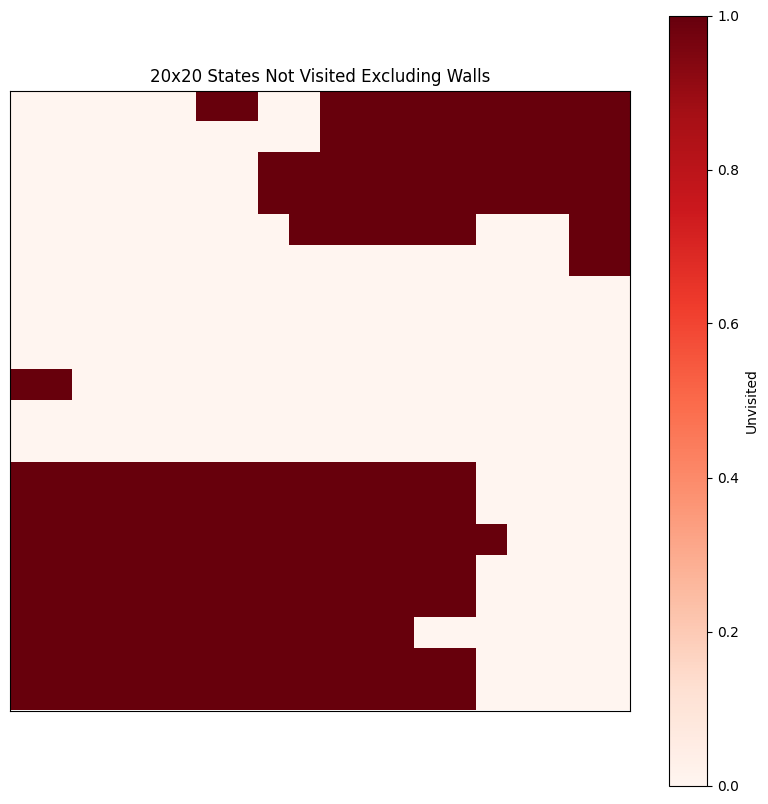

In [34]:
# -----------------------------
# 20x20 dataset coverage diagnostics
# -----------------------------

visited_states_20 = set(df_20["state"].unique())
wall_states_20 = set(mdp_data_20["walls"])
terminal_states_20 = set(mdp_data_20["pits"]) | {mdp_data_20["goal"]}
all_states_20 = set(range(mdp_20.N))

non_visited_non_walls_20 = all_states_20 - visited_states_20 - wall_states_20

print("=" * 50)
print("20x20 STATE COVERAGE")
print("=" * 50)
print(f"Total states:              {mdp_20.N}")
print(f"Walls:                     {len(wall_states_20)}")
print(f"Terminal states:           {len(terminal_states_20)}")
print(f"Visited states:            {len(visited_states_20)}")
print(f"Unvisited non-wall states: {len(non_visited_non_walls_20)}")
print(f"State coverage:            {len(visited_states_20) / (mdp_20.N - len(wall_states_20)):.2%}")

coverage_map_20 = np.zeros((size_20, size_20), dtype=float)

for s in non_visited_non_walls_20:
    r, c = divmod(s, size_20)
    coverage_map_20[r, c] = 1.0

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map_20, cmap="Reds", interpolation="nearest")
plt.title("20x20 States Not Visited Excluding Walls")
plt.colorbar(label="Unvisited")
plt.xticks([])
plt.yticks([])
plt.show()

In [39]:
# -----------------------------
# 20x20 FOGAS solver
# -----------------------------

solver_20 = FOGASSolver(
    mdp=mdp_20,
    phi=phi_20,
    csv_path=str("/shared/home/mauro.diaz/work/FOGAS/data/datasets/20grid.csv"),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_20 = FOGASEvaluator(
    solver=solver_20,
    planner=planner_20,
)

solver_20.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    T=25_000,
    tqdm_print=True,
)

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=16000)


FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:40<00:00, 622.81it/s]


tensor([[0.1797, 0.3898, 0.1674, 0.2631],
        [0.0712, 0.3091, 0.0362, 0.5836],
        [0.0376, 0.2076, 0.0104, 0.7445],
        ...,
        [0.0521, 0.3187, 0.1232, 0.5060],
        [0.0614, 0.4935, 0.1165, 0.3286],
        [0.2353, 0.2567, 0.2347, 0.2732]], device='cuda:0',
       dtype=torch.float64)

In [40]:
goal_state_20 = mdp_data_20["goal"]
terminal_states_20 = set(mdp_data_20["pits"]) | {goal_state_20}

action_names = {
    0: "up",
    1: "down",
    2: "left",
    3: "right",
}

def discounted_return(traj, gamma):
    return sum((gamma ** step["step"]) * step["reward"] for step in traj)

def print_trajectory_debug(traj, size, goal_state, terminal_states, title):
    print("=" * 80)
    print(title)
    print("=" * 80)

    for step in traj:
        s = step["state"]
        ns = step["next_state"]
        sr, sc = divmod(s, size)
        nr, nc = divmod(ns, size)
        a = step["action"]

        flags = []
        if step["was_self_loop"]:
            flags.append("SELF_LOOP")
        if ns == goal_state:
            flags.append("GOAL")
        elif ns in terminal_states:
            flags.append("TERMINAL/PIT")

        flag_text = f"  <-- {', '.join(flags)}" if flags else ""

        print(
            f"t={step['step']:03d} | "
            f"s={s:3d} ({sr:2d},{sc:2d}) | "
            f"a={a} {action_names[a]:>5s} | "
            f"r={step['reward']:7.3f} | "
            f"s'={ns:3d} ({nr:2d},{nc:2d})"
            f"{flag_text}"
        )

    ret = discounted_return(traj, mdp_20.gamma)
    final_next = traj[-1]["next_state"] if traj else None

    print()
    print(f"discounted_return = {ret:.4f}")
    print(f"steps = {len(traj)}")
    print(f"final_next_state = {final_next}")
    print(f"success = {final_next == goal_state}")

    if not traj:
        print("FAILED: empty trajectory")
    elif final_next == goal_state:
        print("OK: reached goal")
    elif final_next in terminal_states:
        print("FAILED: hit terminal non-goal state, likely pit")
    elif len(traj) >= 200:
        print("FAILED: max_steps reached before terminal state")
    elif traj[-1]["was_self_loop"]:
        print("FAILED: ended in self-loop/stuck transition")
    else:
        print("FAILED: stopped without reaching goal")

    print()

# Print learned greedy trajectories
for i in range(10):
    traj = evaluator_20.simulate_trajectory(
        policy_mode="greedy",
        max_steps=200,
        seed=seed + i,
        goal_state=goal_state_20,
        terminal_states=terminal_states_20,
    )

    print_trajectory_debug(
        traj,
        size=size_20,
        goal_state=goal_state_20,
        terminal_states=terminal_states_20,
        title=f"LEARNED GREEDY TRAJECTORY {i}",
    )

# Optional: compare one optimal trajectory
traj_opt = evaluator_20.simulate_trajectory(
    pi=planner_20.pi_star,
    max_steps=200,
    seed=seed,
    goal_state=goal_state_20,
    terminal_states=terminal_states_20,
)

print_trajectory_debug(
    traj_opt,
    size=size_20,
    goal_state=goal_state_20,
    terminal_states=terminal_states_20,
    title="OPTIMAL TRAJECTORY",
)

LEARNED GREEDY TRAJECTORY 0
t=000 | s=  0 ( 0, 0) | a=1  down | r= -0.010 | s'= 20 ( 1, 0)
t=001 | s= 20 ( 1, 0) | a=1  down | r= -0.010 | s'= 40 ( 2, 0)
t=002 | s= 40 ( 2, 0) | a=1  down | r= -0.010 | s'= 60 ( 3, 0)
t=003 | s= 60 ( 3, 0) | a=1  down | r= -0.010 | s'= 80 ( 4, 0)
t=004 | s= 80 ( 4, 0) | a=1  down | r= -0.010 | s'=100 ( 5, 0)
t=005 | s=100 ( 5, 0) | a=1  down | r= -0.010 | s'=120 ( 6, 0)
t=006 | s=120 ( 6, 0) | a=1  down | r= -0.010 | s'=140 ( 7, 0)
t=007 | s=140 ( 7, 0) | a=1  down | r= -0.010 | s'=160 ( 8, 0)
t=008 | s=160 ( 8, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)
t=009 | s=180 ( 9, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)  <-- SELF_LOOP
t=010 | s=180 ( 9, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)  <-- SELF_LOOP
t=011 | s=180 ( 9, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)  <-- SELF_LOOP
t=012 | s=180 ( 9, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)  <-- SELF_LOOP
t=013 | s=180 ( 9, 0) | a=1  down | r= -0.010 | s'=180 ( 9, 0)  <-- SELF_LOOP
t=014 | s=180 (